# Lab 5: Transfer Learning - Cats vs Dogs Classification

## 🎯 Learning Objectives

By the end of this lab, you will:
- Understand transfer learning and why it works
- Use a pre-trained CNN (Convolutional Neural Network) as feature extractor
- Add a custom classification head for binary classification
- Work with image datasets from Kaggle
- Implement data augmentation for better generalization
- Evaluate model performance with appropriate metrics

**What You'll Build:** A cats vs dogs classifier achieving >90% accuracy using transfer learning

**Reference:** [Kaggle Cats vs Dogs CNN](https://www.kaggle.com/code/sachinpatil1280/cats-vs-dogs-image-classification-using-cnn-95/notebook)

**Note:** PyTorch and torchvision are pre-installed in Google Colab!

## Interactive Visualization: 2D Convolution

Understanding how convolutional neural networks "see" images starts with understanding convolution.

**Click 'Step' to see the kernel slide across the input and compute each output value!**

In [1]:
%%html
<style>
#conv-container * { box-sizing: border-box; margin: 0; padding: 0; }
#conv-container { padding: 1rem 0; font-family: sans-serif; font-size: 13px; color: #1a1a1a; }
#conv-container h1 { font-size: 18px; font-weight: 500; margin-bottom: 4px; }
#conv-container .subtitle { font-size: 13px; color: #666; margin-bottom: 20px; }
#conv-container .row { display: flex; align-items: flex-start; gap: 24px; flex-wrap: wrap; justify-content: center; }
#conv-container .section-label { font-size: 11px; font-weight: 500; color: #666; text-align: center; margin-bottom: 6px; letter-spacing: .04em; text-transform: uppercase; }
#conv-container .grid-wrap { display: inline-block; }
#conv-container .grid { display: grid; gap: 3px; }
#conv-container .cell {
  width: 44px; height: 44px; border-radius: 6px; border: 0.5px solid #ccc;
  display: flex; align-items: center; justify-content: center; font-size: 13px; font-weight: 500;
  color: #1a1a1a; background: #fff; transition: background .2s, border-color .2s, color .2s;
}
#conv-container .cell.hi-input { background: #E6F1FB; border-color: #185FA5; color: #0C447C; }
#conv-container .cell.hi-kernel { background: #EEEDFE; border-color: #534AB7; color: #3C3489; }
#conv-container .cell.hi-out { background: #FAEEDA; border-color: #854F0B; color: #633806; }
#conv-container .cell.done { background: #f7f7f5; color: #888; }
#conv-container .cell.active-out { background: #FAEEDA; border-color: #854F0B; color: #633806; }
#conv-container .op-area {
  margin-top: 16px; padding: 14px 16px; border-radius: 10px; border: 0.5px solid #ddd;
  background: #f7f7f5; font-size: 13px; line-height: 1.8; min-height: 72px;
}
#conv-container .term-r { color: #185FA5; font-weight: 500; }
#conv-container .term-p { color: #534AB7; font-weight: 500; }
#conv-container .term-o { color: #854F0B; font-weight: 500; }
#conv-container .sym { color: #888; }
#conv-container .controls { display: flex; flex-wrap: wrap; gap: 12px; margin-top: 14px; align-items: center; }
#conv-container .ctrl-group { display: flex; align-items: center; gap: 8px; font-size: 12px; color: #666; }
#conv-container select {
  font-size: 12px; padding: 4px 8px; border-radius: 6px; border: 0.5px solid #ccc;
  background: #fff; color: #1a1a1a;
}
#conv-container .btn {
  padding: 5px 14px; border-radius: 6px; border: 0.5px solid #ccc; background: transparent;
  color: #1a1a1a; font-size: 12px; cursor: pointer;
}
#conv-container .btn:hover { background: #f0f0ee; }
#conv-container .btn.primary { border-color: #185FA5; color: #185FA5; }
#conv-container .btn.primary:hover { background: #E6F1FB; }
#conv-container .btn:disabled { opacity: 0.5; cursor: not-allowed; }
#conv-container .step-row { display: flex; gap: 8px; margin-top: 14px; align-items: center; }
#conv-container .prog { flex: 1; height: 4px; border-radius: 2px; background: #ddd; overflow: hidden; }
#conv-container .prog-bar { height: 100%; background: #185FA5; border-radius: 2px; transition: width .3s; }
#conv-container .legend { display: flex; gap: 16px; flex-wrap: wrap; margin-top: 12px; font-size: 11px; color: #666; }
#conv-container .leg { display: flex; align-items: center; gap: 5px; }
#conv-container .leg-dot { width: 12px; height: 12px; border-radius: 3px; flex-shrink: 0; }
</style>

<div id="conv-container">
  <h1>2D Convolution — How CNNs "See" Images</h1>
  <p class="subtitle">Step through the sliding kernel to see how each output value is computed.</p>

  <div class="row">
    <div class="grid-wrap">
      <div class="section-label">Input (5×5)</div>
      <div class="grid" style="grid-template-columns:repeat(5,44px)" id="conv-gridInput"></div>
    </div>
    <div style="display:flex;flex-direction:column;align-items:center;justify-content:center;padding-top:28px;gap:6px">
      <div style="font-size:18px;color:#888">*</div>
      <div style="font-size:10px;color:#aaa">convolve</div>
    </div>
    <div class="grid-wrap">
      <div class="section-label">Kernel (3×3)</div>
      <div class="grid" style="grid-template-columns:repeat(3,44px)" id="conv-gridKernel"></div>
    </div>
    <div style="display:flex;flex-direction:column;align-items:center;justify-content:center;padding-top:28px;gap:6px">
      <div style="font-size:18px;color:#888">=</div>
    </div>
    <div class="grid-wrap">
      <div class="section-label">Feature map (3×3)</div>
      <div class="grid" style="grid-template-columns:repeat(3,44px)" id="conv-gridOutput"></div>
    </div>
  </div>

  <div class="op-area" id="conv-opArea">
    <span style="color:#888">Press <b>Step</b> to slide the kernel and compute one output cell at a time.</span>
  </div>

  <div class="step-row">
    <button class="btn" onclick="convReset()">↺ Reset</button>
    <button class="btn primary" onclick="convStepFwd()" id="conv-btnStep">Step →</button>
    <div class="prog"><div class="prog-bar" id="conv-progBar" style="width:0%"></div></div>
    <span style="font-size:11px;color:#666;min-width:40px;text-align:right" id="conv-stepLabel">0 / 9</span>
  </div>

  <div class="controls">
    <div class="ctrl-group">
      <span>Kernel preset:</span>
      <select id="conv-kernelSelect" onchange="convApplyPreset()">
        <option value="edge">Edge detector</option>
        <option value="blur">Blur (average)</option>
        <option value="sharpen">Sharpen</option>
        <option value="identity">Identity</option>
      </select>
    </div>
  </div>

  <div class="legend">
    <div class="leg"><div class="leg-dot" style="background:#E6F1FB;border:1px solid #185FA5"></div> Input patch (active)</div>
    <div class="leg"><div class="leg-dot" style="background:#EEEDFE;border:1px solid #534AB7"></div> Kernel weights</div>
    <div class="leg"><div class="leg-dot" style="background:#FAEEDA;border:1px solid #854F0B"></div> Output value</div>
  </div>
</div>

<script>
(function() {
  const INPUT = [
    [1,2,3,0,1],
    [0,1,2,3,1],
    [2,1,0,1,2],
    [1,3,2,1,0],
    [0,1,1,2,3]
  ];

  const PRESETS = {
    edge:     [[-1,-1,-1],[-1,8,-1],[-1,-1,-1]],
    blur:     [[1,1,1],[1,1,1],[1,1,1]],
    sharpen:  [[0,-1,0],[-1,5,-1],[0,-1,0]],
    identity: [[0,0,0],[0,1,0],[0,0,0]]
  };

  let kernel = PRESETS.edge.map(r=>[...r]);
  let step = 0;
  const TOTAL = 9;

  function getPos(s){ return [Math.floor(s/3), s%3]; }

  function computeOutput(ri, ci){
    let sum = 0;
    for(let kr=0;kr<3;kr++) for(let kc=0;kc<3;kc++) sum += INPUT[ri+kr][ci+kc]*kernel[kr][kc];
    return sum;
  }

  function allOutputs(){
    const O=[];
    for(let r=0;r<3;r++){O.push([]); for(let c=0;c<3;c++) O[r].push(computeOutput(r,c));}
    return O;
  }

  function renderInput(hiR, hiC){
    const el=document.getElementById('conv-gridInput');
    if (!el) return;
    el.innerHTML='';
    for(let r=0;r<5;r++) for(let c=0;c<5;c++){
      const d=document.createElement('div');
      d.className='cell';
      d.textContent=INPUT[r][c];
      if(hiR!==null && r>=hiR && r<hiR+3 && c>=hiC && c<hiC+3) d.classList.add('hi-input');
      el.appendChild(d);
    }
  }

  function renderKernel(highlight){
    const el=document.getElementById('conv-gridKernel');
    if (!el) return;
    el.innerHTML='';
    for(let r=0;r<3;r++) for(let c=0;c<3;c++){
      const d=document.createElement('div');
      d.className='cell';
      d.textContent=kernel[r][c];
      if(highlight) d.classList.add('hi-kernel');
      el.appendChild(d);
    }
  }

  function renderOutput(upTo, activeR, activeC){
    const el=document.getElementById('conv-gridOutput');
    if (!el) return;
    el.innerHTML='';
    const O=allOutputs();
    for(let r=0;r<3;r++) for(let c=0;c<3;c++){
      const d=document.createElement('div');
      d.className='cell';
      const idx=r*3+c;
      if(idx<upTo){ d.textContent=O[r][c]; d.classList.add('done'); }
      else if(r===activeR && c===activeC){ d.textContent=O[r][c]; d.classList.add('active-out'); }
      else{ d.textContent='?'; }
      el.appendChild(d);
    }
  }

  function buildOpHTML(ri, ci){
    const pairs=[];
    for(let kr=0;kr<3;kr++) for(let kc=0;kc<3;kc++){
      const iv=INPUT[ri+kr][ci+kc], kv=kernel[kr][kc];
      pairs.push(`<span class="term-r">${iv}</span><span class="sym">×</span><span class="term-p">${kv}</span>`);
    }
    const sum=computeOutput(ri,ci);
    const nums=[];
    for(let kr=0;kr<3;kr++) for(let kc=0;kc<3;kc++) nums.push(INPUT[ri+kr][ci+kc]*kernel[kr][kc]);
    return `
      <div><b>Output[${ri}][${ci}]</b> — element-wise multiply patch × kernel, then sum</div>
      <div style="margin-top:6px;line-height:2">${pairs.join('<span class="sym"> + </span>')}</div>
      <div style="margin-top:6px">= <span style="color:#888">${nums.join(' + ')}</span> = <span class="term-o" style="font-size:15px">${sum}</span></div>`;
  }

  function render(){
    if(step===0){
      renderInput(null,null);
      renderKernel(false);
      renderOutput(-1,null,null);
      const opArea = document.getElementById('conv-opArea');
      if (opArea) opArea.innerHTML='<span style="color:#888">Press <b>Step</b> to slide the kernel and compute one output cell at a time.</span>';
    } else {
      const [ri,ci]=getPos(step-1);
      renderInput(ri,ci);
      renderKernel(true);
      renderOutput(step-1,ri,ci);
      const opArea = document.getElementById('conv-opArea');
      if (opArea) opArea.innerHTML=buildOpHTML(ri,ci);
    }
    const pct=Math.round(step/TOTAL*100);
    const progBar = document.getElementById('conv-progBar');
    if (progBar) progBar.style.width=pct+'%';
    const stepLabel = document.getElementById('conv-stepLabel');
    if (stepLabel) stepLabel.textContent=step+' / '+TOTAL;
    const btnStep = document.getElementById('conv-btnStep');
    if (btnStep) {
      btnStep.disabled=(step>=TOTAL);
      btnStep.textContent=step>=TOTAL ? 'Done!' : 'Step →';
    }
  }

  window.convStepFwd = function(){ if(step<TOTAL){step++; render();} };
  window.convReset = function(){ step=0; render(); };

  window.convApplyPreset = function(){
    const sel = document.getElementById('conv-kernelSelect');
    if (!sel) return;
    const v=sel.value;
    kernel=PRESETS[v].map(r=>[...r]);
    step=0; render();
  };

  render();
})();
</script>


## Interactive Visualization: Activation Functions & Derivatives

Understanding activation functions is crucial for building neural networks. Each function shapes how gradients flow during backpropagation.

**Click tabs to explore different activation functions. Use the slider to see how f(x) and f'(x) change at different input values!**

In [2]:
%%html
<style>
#activation-container * { box-sizing: border-box; margin: 0; padding: 0; }
#activation-container { padding: 1rem 0; font-family: sans-serif; color: #1a1a1a; }
#activation-container h1 { font-size: 18px; font-weight: 500; margin-bottom: 4px; }
#activation-container .subtitle { font-size: 13px; color: #666; margin-bottom: 20px; }
#activation-container .tabs { display: flex; flex-wrap: wrap; gap: 6px; margin-bottom: 16px; }
#activation-container .tab {
  padding: 6px 14px; border-radius: 20px; border: 0.5px solid #ccc; background: transparent;
  color: #666; font-size: 12px; cursor: pointer; transition: all .15s;
}
#activation-container .tab:hover { background: #f0f0ee; }
#activation-container .tab.active { font-weight: 500; }
#activation-container .main { display: flex; gap: 20px; flex-wrap: wrap; align-items: flex-start; }
#activation-container .charts { flex: 1; min-width: 300px; display: flex; flex-direction: column; gap: 8px; }
#activation-container .chart-label {
  font-size: 11px; font-weight: 500; color: #666; text-transform: uppercase;
  letter-spacing: .04em; margin-bottom: 4px;
}
#activation-container canvas {
  width: 100%; border-radius: 10px; border: 0.5px solid #ddd; display: block;
}
#activation-container .info-card {
  width: 220px; flex-shrink: 0; border: 0.5px solid #ddd; border-radius: 10px;
  padding: 14px; background: #f7f7f5;
}
#activation-container .fn-name { font-size: 15px; font-weight: 500; margin-bottom: 4px; }
#activation-container .fn-formula {
  font-family: monospace; font-size: 11px; color: #666; margin-bottom: 8px;
  padding: 6px 8px; background: #fff; border-radius: 6px; border: 0.5px solid #ddd; line-height: 1.6;
}
#activation-container .prop { margin-bottom: 8px; }
#activation-container .prop-label {
  font-size: 11px; font-weight: 500; color: #666; text-transform: uppercase;
  letter-spacing: .04em; margin-bottom: 2px;
}
#activation-container .prop-val { font-size: 12px; color: #1a1a1a; line-height: 1.5; }
#activation-container .badge {
  display: inline-block; padding: 2px 8px; border-radius: 10px; font-size: 11px; margin: 2px 2px 0 0;
}
#activation-container .badge.green { background: #EAF3DE; color: #27500A; border: 0.5px solid #3B6D11; }
#activation-container .badge.amber { background: #FAEEDA; color: #633806; border: 0.5px solid #854F0B; }
#activation-container .probe-row {
  display: flex; align-items: center; gap: 6px; margin-top: 12px; font-size: 12px;
  color: #666; flex-wrap: wrap;
}
#activation-container .probe-row input { flex: 1; min-width: 80px; }
#activation-container .probe-vals { display: flex; gap: 10px; margin-top: 6px; font-size: 12px; }
#activation-container .probe-val { display: flex; flex-direction: column; align-items: center; gap: 2px; }
#activation-container .probe-val span:first-child { font-size: 10px; color: #666; }
#activation-container .compare-toggle {
  margin-top: 10px; display: flex; align-items: center; gap: 8px; font-size: 12px;
  color: #666; cursor: pointer;
}
#activation-container .divider { border: none; border-top: 0.5px solid #ddd; margin: 10px 0; }
</style>

<div id="activation-container">
  <h1>Activation Functions & Derivatives</h1>
  <p class="subtitle">Explore how different activation functions shape gradients in neural networks.</p>

  <div class="tabs" id="activation-tabs"></div>
  <div class="main">
    <div class="charts">
      <div>
        <div class="chart-label">f(x) — activation</div>
        <canvas id="activation-chartFn" height="200"></canvas>
      </div>
      <div>
        <div class="chart-label">f′(x) — derivative (gradient flow)</div>
        <canvas id="activation-chartDeriv" height="200"></canvas>
      </div>
      <label class="compare-toggle">
        <input type="checkbox" id="activation-compareAll" onchange="activationRender()">
        <span>Overlay all functions</span>
      </label>
    </div>
    <div class="info-card" id="activation-infoCard"></div>
  </div>
</div>

<script>
(function() {
  const FNS = [
    {
      id:'relu', name:'ReLU', color:'#185FA5',
      formula:'f(x) = max(0, x)',
      dformula:"f'(x) = 0 if x < 0\n         1 if x > 0",
      fn:  x => Math.max(0, x),
      dfn: x => x > 0 ? 1 : 0,
      drange:'0 or 1',
      dNote:'Gradient is 1 for positive inputs, 0 otherwise. Dead neurons (x<0) send zero gradient — weights never update.',
      pros:['Fast to compute','No vanishing gradient (x>0)'],
      cons:['Dying ReLU: zero gradient for x<0'],
      usedIn:'CNNs, ResNets',
      note:'Default choice for hidden layers.'
    },
    {
      id:'gelu', name:'GELU', color:'#534AB7',
      formula:'f(x) = x · Φ(x)',
      dformula:"f'(x) = Φ(x) + x · φ(x)\n(Φ = CDF, φ = PDF of N(0,1))",
      fn:  x => x*0.5*(1+Math.tanh(Math.sqrt(2/Math.PI)*(x+0.044715*x*x*x))),
      dfn: x => {
        const t=Math.tanh(Math.sqrt(2/Math.PI)*(x+0.044715*x*x*x));
        const sech2=1-t*t;
        return 0.5*(1+t)+0.5*x*sech2*Math.sqrt(2/Math.PI)*(1+3*0.044715*x*x);
      },
      drange:'≈ (−0.1, 1.1)',
      dNote:'Smooth, non-zero gradient everywhere. Slightly exceeds 1 near x≈0.75 — this helps learning in deep networks.',
      pros:['Smooth gradient everywhere','Stronger signal than ReLU near 0'],
      cons:['More expensive to compute'],
      usedIn:'BERT, GPT, Transformers',
      note:'Used in modern LLMs. Self-gated by input probability.'
    },
    {
      id:'sigmoid', name:'Sigmoid', color:'#993C1D',
      formula:'f(x) = 1 / (1 + e⁻ˣ)',
      dformula:"f'(x) = f(x) · (1 − f(x))",
      fn:  x => 1/(1+Math.exp(-x)),
      dfn: x => { const s=1/(1+Math.exp(-x)); return s*(1-s); },
      drange:'(0, 0.25]',
      dNote:'Max gradient is 0.25 (at x=0). Saturates near 0 for large |x| — gradients vanish, making deep nets hard to train.',
      pros:['Clean probabilistic formula'],
      cons:['Vanishing gradient for large |x|','Max gradient only 0.25'],
      usedIn:'Output layer (binary classification)',
      note:'Rarely used in hidden layers due to vanishing gradients.'
    },
    {
      id:'tanh', name:'Tanh', color:'#0F6E56',
      formula:'f(x) = (eˣ − e⁻ˣ) / (eˣ + e⁻ˣ)',
      dformula:"f'(x) = 1 − f(x)²\n       = sech²(x)",
      fn:  x => Math.tanh(x),
      dfn: x => { const t=Math.tanh(x); return 1-t*t; },
      drange:'(0, 1]',
      dNote:'Max gradient is 1 at x=0. Better than sigmoid (stronger gradient, zero-centered), but still vanishes for large |x|.',
      pros:['Stronger gradient than sigmoid','Zero-centered output'],
      cons:['Still vanishes for large |x|'],
      usedIn:'RNNs, LSTMs',
      note:'Preferred over sigmoid for hidden layers in recurrent nets.'
    },
    {
      id:'leaky', name:'Leaky ReLU', color:'#854F0B',
      formula:'f(x) = x if x>0, else 0.01x',
      dformula:"f'(x) = 1    if x > 0\n         0.01 if x < 0",
      fn:  x => x>0 ? x : 0.01*x,
      dfn: x => x>0 ? 1 : 0.01,
      drange:'0.01 or 1',
      dNote:'Gradient is always non-zero (0.01 for x<0). Fixes the dying ReLU problem — neurons can recover during training.',
      pros:['No dead neurons','Near-zero gradient for x<0'],
      cons:['α=0.01 is a tunable hyperparameter'],
      usedIn:'GANs, deep networks',
      note:'PReLU learns α. ELU uses an exponential for smoother negative region.'
    },
    {
      id:'swish', name:'Swish', color:'#D4537E',
      formula:'f(x) = x · sigmoid(x)',
      dformula:"f'(x) = f(x) + σ(x)·(1 − f(x))",
      fn:  x => x*(1/(1+Math.exp(-x))),
      dfn: x => {
        const s=1/(1+Math.exp(-x));
        const fx=x*s;
        return fx+s*(1-fx);
      },
      drange:'≈ (−0.1, 1.1)',
      dNote:'Similar shape to GELU derivative. Non-monotonic: slightly negative for x≈−1, enabling the model to suppress small negative signals selectively.',
      pros:['Smooth non-monotonic gradient','Found by neural architecture search'],
      cons:['Slightly heavier compute than ReLU'],
      usedIn:'EfficientNet, MobileNet',
      note:'Self-gated. Outperforms ReLU on many deep architectures.'
    },
  ];

  let active='relu';
  const X_MIN=-4, X_MAX=4, STEPS=400;

  function isDark(){ return window.matchMedia&&window.matchMedia('(prefers-color-scheme:dark)').matches; }
  function getC(){
    const d=isDark();
    return {
      grid: d?'rgba(255,255,255,0.07)':'rgba(0,0,0,0.06)',
      axis: d?'rgba(255,255,255,0.2)':'rgba(0,0,0,0.18)',
      text: d?'#9c9a92':'#73726c',
      bg:   d?'#1e1e1c':'#ffffff',
    };
  }

  function xs(){ return Array.from({length:STEPS},(_,i)=>X_MIN+(X_MAX-X_MIN)*i/(STEPS-1)); }

  function drawCanvas(canvasId, evalFn, yMin, yMax, probeX, color, compareAll, dashed){
    const canvas=document.getElementById(canvasId);
    if (!canvas) return;
    const dpr=window.devicePixelRatio||1;
    const W=canvas.offsetWidth, H=canvas.offsetHeight||200;
    canvas.width=W*dpr; canvas.height=H*dpr;
    const ctx=canvas.getContext('2d');
    ctx.scale(dpr,dpr);
    const C=getC();
    const PAD={l:38,r:16,t:12,b:28};
    const cw=W-PAD.l-PAD.r, ch=H-PAD.t-PAD.b;

    ctx.fillStyle=C.bg; ctx.fillRect(0,0,W,H);

    function px(x){ return PAD.l+((x-X_MIN)/(X_MAX-X_MIN))*cw; }
    function py(y){ return PAD.t+((yMax-y)/(yMax-yMin))*ch; }

    // grid
    ctx.strokeStyle=C.grid; ctx.lineWidth=0.5;
    const yTicks=[yMin, 0, yMax].filter((v,i,a)=>a.indexOf(v)===i);
    yTicks.forEach(y=>{ ctx.beginPath(); ctx.moveTo(PAD.l,py(y)); ctx.lineTo(PAD.l+cw,py(y)); ctx.stroke(); });
    [-3,-2,-1,0,1,2,3].forEach(x=>{ ctx.beginPath(); ctx.moveTo(px(x),PAD.t); ctx.lineTo(px(x),PAD.t+ch); ctx.stroke(); });

    // axes
    ctx.strokeStyle=C.axis; ctx.lineWidth=1;
    if(yMin<0&&yMax>0){ ctx.beginPath(); ctx.moveTo(PAD.l,py(0)); ctx.lineTo(PAD.l+cw,py(0)); ctx.stroke(); }
    ctx.beginPath(); ctx.moveTo(px(0),PAD.t); ctx.lineTo(px(0),PAD.t+ch); ctx.stroke();

    // tick labels
    ctx.fillStyle=C.text; ctx.font='10px sans-serif';
    ctx.textAlign='right';
    yTicks.forEach(y=>ctx.fillText(y%1===0?y:y.toFixed(1), PAD.l-4, py(y)+3));
    ctx.textAlign='center';
    [-3,-1,0,1,3].forEach(x=>ctx.fillText(x, px(x), PAD.t+ch+14));

    const toShow=compareAll?FNS:[FNS.find(f=>f.id===active)];

    toShow.forEach(fn=>{
      const isActive=fn.id===active;
      ctx.beginPath();
      ctx.strokeStyle=fn.color;
      ctx.lineWidth=compareAll&&!isActive?1.2:2.2;
      ctx.globalAlpha=compareAll&&!isActive?0.35:1;
      if(dashed&&!isActive){ ctx.setLineDash([4,4]); } else { ctx.setLineDash([]); }
      xs().forEach((x,i)=>{
        let y=evalFn(fn,x);
        y=Math.max(yMin-0.5,Math.min(yMax+0.5,y));
        if(i===0) ctx.moveTo(px(x),py(Math.max(yMin,Math.min(yMax,y))));
        else ctx.lineTo(px(x),py(Math.max(yMin,Math.min(yMax,y))));
      });
      ctx.stroke();
      ctx.setLineDash([]);
      ctx.globalAlpha=1;

      if(compareAll){
        const ex=X_MAX-0.1;
        let ey=evalFn(fn,ex);
        ey=Math.max(yMin,Math.min(yMax,ey));
        ctx.fillStyle=fn.color; ctx.font='bold 10px sans-serif'; ctx.textAlign='left';
        ctx.fillText(fn.name, Math.min(px(ex)+2, W-55), py(ey)+3);
      }
    });

    // probe dot + crosshairs
    if(probeX!==null){
      const fn=FNS.find(f=>f.id===active);
      let py_val=evalFn(fn,probeX);
      py_val=Math.max(yMin,Math.min(yMax,py_val));
      ctx.strokeStyle=fn.color; ctx.lineWidth=1; ctx.setLineDash([3,3]); ctx.globalAlpha=0.5;
      ctx.beginPath(); ctx.moveTo(px(probeX),py(0)); ctx.lineTo(px(probeX),py(py_val)); ctx.stroke();
      ctx.beginPath(); ctx.moveTo(PAD.l,py(py_val)); ctx.lineTo(px(probeX),py(py_val)); ctx.stroke();
      ctx.setLineDash([]); ctx.globalAlpha=1;
      ctx.fillStyle=fn.color;
      ctx.beginPath(); ctx.arc(px(probeX),py(py_val),4,0,Math.PI*2); ctx.fill();
    }
  }

  function renderCharts(probeX){
    const compareAll=document.getElementById('activation-compareAll')?.checked;
    drawCanvas('activation-chartFn',  (fn,x)=>fn.fn(x),  -1.5, 1.5, probeX, null, compareAll, false);
    drawCanvas('activation-chartDeriv',(fn,x)=>fn.dfn(x), -0.2, 1.2, probeX, null, compareAll, true);
  }

  function renderInfo(){
    const fn=FNS.find(f=>f.id===active);
    const slider = document.getElementById('activation-probeSlider');
    const xv=parseFloat(slider?.value||0);
    const fv=fn.fn(xv), dv=fn.dfn(xv);
    const infoCard = document.getElementById('activation-infoCard');
    if (!infoCard) return;
    infoCard.innerHTML=`
      <div class="fn-name" style="color:${fn.color}">${fn.name}</div>
      <div class="prop-label" style="margin-bottom:4px">f(x)</div>
      <div class="fn-formula">${fn.formula}</div>
      <div class="prop-label" style="margin-bottom:4px">f′(x)</div>
      <div class="fn-formula">${fn.dformula}</div>
      <hr class="divider">
      <div class="prop"><div class="prop-label">Derivative range</div><div class="prop-val">${fn.drange}</div></div>
      <div class="prop"><div class="prop-label">Gradient insight</div><div class="prop-val" style="color:#666;font-size:11px;line-height:1.5">${fn.dNote}</div></div>
      <div class="prop"><div class="prop-label">Pros</div><div class="prop-val">${fn.pros.map(p=>`<span class="badge green">${p}</span>`).join('')}</div></div>
      <div class="prop"><div class="prop-label">Cons</div><div class="prop-val">${fn.cons.map(p=>`<span class="badge amber">${p}</span>`).join('')}</div></div>
      <hr class="divider">
      <div class="probe-row">
        <span>Probe x:</span>
        <input type="range" id="activation-probeSlider" min="-4" max="4" step="0.1" value="${xv}" oninput="activationOnProbe(this.value)">
        <span id="activation-probeXLbl" style="min-width:28px">${xv.toFixed(1)}</span>
      </div>
      <div class="probe-vals">
        <div class="probe-val">
          <span>f(x)</span>
          <span style="font-size:13px;font-weight:500;color:${fn.color}" id="activation-probeFval">${fv.toFixed(3)}</span>
        </div>
        <div class="probe-val">
          <span>f′(x)</span>
          <span style="font-size:13px;font-weight:500;color:${fn.color};opacity:.7" id="activation-probeDval">${dv.toFixed(3)}</span>
        </div>
      </div>`;
  }

  window.activationOnProbe = function(v){
    const fn=FNS.find(f=>f.id===active);
    const xv=parseFloat(v);
    const lbl = document.getElementById('activation-probeXLbl');
    const fval = document.getElementById('activation-probeFval');
    const dval = document.getElementById('activation-probeDval');
    if (lbl) lbl.textContent=xv.toFixed(1);
    if (fval) fval.textContent=fn.fn(xv).toFixed(3);
    if (dval) dval.textContent=fn.dfn(xv).toFixed(3);
    renderCharts(xv);
  };

  window.activationRender = function(){
    renderTabs();
    renderInfo();
    const slider = document.getElementById('activation-probeSlider');
    const xv=parseFloat(slider?.value||0);
    renderCharts(xv);
  };

  function renderTabs(){
    const tabs = document.getElementById('activation-tabs');
    if (!tabs) return;
    tabs.innerHTML=FNS.map(f=>`
      <button class="tab${f.id===active?' active':''}" onclick="activationSetActive('${f.id}')"
        style="${f.id===active?`border-color:${f.color};background:${f.color}22;color:${f.color}`:''}">
        ${f.name}
      </button>`).join('');
  }

  window.activationSetActive = function(id){ active=id; activationRender(); };

  activationRender();
  window.addEventListener('resize', ()=>{
    const slider = document.getElementById('activation-probeSlider');
    const xv=parseFloat(slider?.value||0);
    renderCharts(xv);
  });
})();
</script>


### Key Concepts Explained

Before we start coding, let's understand the key concepts for this lab:

#### 1. Convolutional Neural Networks (CNNs)

**What are CNNs?**
- Specialized neural networks for images
- Use **convolutional layers** that detect patterns (edges, textures, shapes)
- Learn hierarchical features: edges → textures → parts → objects

**Why CNNs for images?**
- Preserve spatial structure (unlike flattening to 1D)
- Parameter sharing (same filter applied everywhere)
- Translation invariant (detect cat anywhere in image)

**CNN Architecture:**
```
Input Image
  ↓
Conv layers (detect features)
  ↓
Pooling (reduce size)
  ↓
More Conv + Pooling
  ↓
Flatten
  ↓
Fully connected layers
  ↓
Output
```

#### 2. ReLU Activation Function

**Definition:** `ReLU(x) = max(0, x)`
- If x > 0: output = x
- If x ≤ 0: output = 0

**Why ReLU?**
- Introduces non-linearity (without it, deep networks = linear model)
- Computationally efficient (just a comparison)
- Helps with gradient flow (no vanishing gradient for positive values)
- Most common activation in modern networks

**Example:**
```python
x = [-2, -1, 0, 1, 2]
relu(x) = [0, 0, 0, 1, 2]
```

#### 3. Dropout

**What is Dropout?**
- Randomly \"drop\" (set to 0) some neurons during training
- Typical rate: 0.5 (drop 50% of neurons)
- At test time: use all neurons (no dropping)

**Why Dropout prevents overfitting:**
- Forces network to not rely on any single neuron
- Creates ensemble effect (each iteration is different network)
- Network learns more robust features

**During training:**
```
Input: [1.0, 2.0, 3.0, 4.0]
After Dropout(0.5): [0, 2.0, 0, 4.0]  (random mask)
```

**During inference:**
```
Input: [1.0, 2.0, 3.0, 4.0]
Output: [1.0, 2.0, 3.0, 4.0]  (no dropout)
```

#### 4. Sigmoid Activation for Binary Classification

**Definition:** `sigmoid(x) = 1 / (1 + e^(-x))`
- Outputs value between 0 and 1
- Interprets as probability

**For binary classification:**
```
Raw output (logit): 2.5
After sigmoid: 0.924
Interpretation: 92.4% confident it's class 1 (dog)

If probability > 0.5: predict class 1 (dog)
If probability ≤ 0.5: predict class 0 (cat)
```

#### 5. BCEWithLogitsLoss

**What it does:**
- Combines sigmoid + Binary Cross Entropy in one operation
- More numerically stable than doing them separately

**Formula:**
```
loss = -[y*log(sigmoid(x)) + (1-y)*log(1-sigmoid(x))]
```

**Why use it:**
- Avoids numerical instability of computing sigmoid then log
- Standard for binary classification
- Don't add sigmoid to your model - BCEWithLogitsLoss expects raw logits

#### 6. Data Augmentation

**What is it?**
- Randomly transform training images to create variations
- Helps model generalize to new images

**Common augmentations:**
- **Horizontal flip:** Mirror image left-right
- **Rotation:** Rotate ±10 degrees
- **Crop:** Random crop then resize
- **Color jitter:** Change brightness/contrast

**Why it helps:**
- Model sees more variations
- Learns invariance (cat is cat even if flipped)
- Reduces overfitting
- Effectively increases dataset size

**Important:** Only augment training data, not validation!

#### 7. ImageNet Normalization

**Why normalize?**
- Pre-trained models expect ImageNet-normalized inputs
- Mean=[0.485, 0.456, 0.406], Std=[0.229, 0.224, 0.225]
- These are RGB channel statistics from ImageNet dataset

**What it does:**
```
normalized = (image - mean) / std
```
- Centers data around 0
- Scales to similar ranges
- Helps model training stability

### Visualizing ReLU and Dropout

Demo 1: ReLU Activation


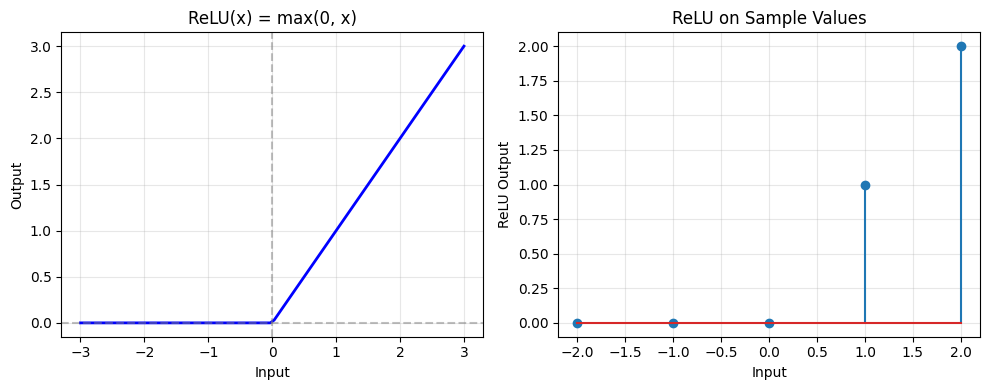

Notice: Negative values become 0, positive values unchanged

Demo 2: Dropout
Original: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
After Dropout (train mode): [2.0, 0.0, 2.0, 0.0, 0.0, 0.0, 2.0, 2.0, 2.0, 0.0]
Notice: About 50% are set to 0, rest are scaled up
After Dropout (eval mode): [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
Notice: No dropout in eval mode

✓ ReLU and Dropout demonstrated!


In [5]:
import random
import numpy as np

# Set random seeds for reproducibility
np.random.seed(42)
random.seed(42)

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

print("=" * 60)
print("Demo 1: ReLU Activation")
print("=" * 60)

# Create sample data
x = torch.linspace(-3, 3, 100)
y_relu = torch.relu(x)

plt.figure(figsize=(10, 4))

# Plot ReLU function
plt.subplot(1, 2, 1)
plt.plot(x.numpy(), y_relu.numpy(), linewidth=2, color='blue')
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('Input')
plt.ylabel('Output')
plt.title('ReLU(x) = max(0, x)')
plt.grid(True, alpha=0.3)

# Show effect on sample values
sample_inputs = torch.tensor([-2.0, -1.0, 0.0, 1.0, 2.0])
sample_outputs = torch.relu(sample_inputs)
plt.subplot(1, 2, 2)
plt.stem(sample_inputs.numpy(), sample_outputs.numpy())
plt.xlabel('Input')
plt.ylabel('ReLU Output')
plt.title('ReLU on Sample Values')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Notice: Negative values become 0, positive values unchanged")

# Separator
print()
print("=" * 60)
print("Demo 2: Dropout")
print("=" * 60)

# Demo dropout
dropout = nn.Dropout(0.5)
x = torch.ones(10)

print("Original:", x.tolist())

# Training mode (dropout active)
dropout.train()
y_train = dropout(x)
print("After Dropout (train mode):", y_train.tolist())
print("Notice: About 50% are set to 0, rest are scaled up")

# Eval mode (no dropout)
dropout.eval()
y_eval = dropout(x)
print("After Dropout (eval mode):", y_eval.tolist())
print("Notice: No dropout in eval mode")

print()
print("✓ ReLU and Dropout demonstrated!")

**Setup:** Check GPU availability (Colab provides free T4 GPU!)

In [6]:
import torch

# Detect device (GPU if available, otherwise CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Using device: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print("\n✓ GPU detected! Training will be fast.")
else:
    print("\n⚠️  No GPU detected. Training will be slower.")
    print("In Colab: Runtime → Change runtime type → Hardware accelerator → T4 GPU")

Using device: cpu

⚠️  No GPU detected. Training will be slower.
In Colab: Runtime → Change runtime type → Hardware accelerator → T4 GPU


## Part 1: What is Transfer Learning?

### The Big Idea

Instead of training a CNN from scratch (which requires millions of images and days of training), we:
1. **Use a pre-trained model** (trained on ImageNet - 14M images, 1000 classes)
2. **Freeze the feature extractor** (keep learned patterns: edges, textures, shapes)
3. **Add a new classification head** (train only this part for our specific task)

### Why Transfer Learning Works

**Low-level features** (edges, corners, colors) are universal:
- A ResNet trained on ImageNet learned to detect edges, textures, shapes
- These same features are useful for cats vs dogs!
- No need to relearn them

**Benefits:**
- ✅ **Faster training** (minutes vs days)
- ✅ **Less data needed** (thousands vs millions)
- ✅ **Better accuracy** (pre-trained features are high quality)
- ✅ **Less compute** (fine-tune on CPU or small GPU)

### Architecture

```
Input Image (3×224×224)
        ↓
Pre-trained ResNet18 (frozen) ← Trained on ImageNet
        ↓
Feature Vector (512 dimensions)
        ↓
Custom Head (trainable) ← We train this!
  - FC Layer 1: 512 → 128
  - ReLU
  - Dropout
  - FC Layer 2: 128 → 1
  - Sigmoid
        ↓
Output (0 = cat, 1 = dog)
```

## Part 2: Dataset Setup

### Kaggle Cats vs Dogs Dataset

**Dataset:** [Dogs vs Cats on Kaggle](https://www.kaggle.com/c/dogs-vs-cats/data)
- 25,000 labeled images
- 12,500 cats, 12,500 dogs
- Various sizes and orientations

### Downloading the Dataset

**Option 1: Direct Kaggle API (Recommended)**

### Downloading Dataset with Kaggle Hub

**New Way:** We'll use `kagglehub` which is simpler than the Kaggle CLI!

**Benefits:**
- No manual token upload needed
- Automatic authentication in Colab
- Simpler API
- Handles caching automatically

**Dataset:** [Cat and Dog Dataset](https://www.kaggle.com/datasets/tongpython/cat-and-dog)

In [7]:
# Install kagglehub
!pip install -q kagglehub

print("✓ kagglehub installed!")

✓ kagglehub installed!


### Download the Dataset

This will download the cat and dog dataset (~500MB):

In [8]:
import kagglehub

# Download latest version
print("Downloading dataset... (this may take 2-3 minutes)")
path = kagglehub.dataset_download("tongpython/cat-and-dog")

print(f"\n✓ Dataset downloaded to: {path}")
print("\nInspecting contents...")

# Inspect the contents to find train/test folders
!ls -R {path}

print("\n✓ Dataset ready!")

/Users/hehuimin/src/dev/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



✓ Dataset downloaded to: /Users/hehuimin/.cache/kagglehub/datasets/tongpython/cat-and-dog/versions/1

Inspecting contents...
test_set     training_set

/Users/hehuimin/.cache/kagglehub/datasets/tongpython/cat-and-dog/versions/1/test_set:
test_set

/Users/hehuimin/.cache/kagglehub/datasets/tongpython/cat-and-dog/versions/1/test_set/test_set:
cats dogs

/Users/hehuimin/.cache/kagglehub/datasets/tongpython/cat-and-dog/versions/1/test_set/test_set/cats:
_DS_Store       cat.4199.jpg    cat.4400.jpg    cat.4603.jpg    cat.4803(1).jpg
cat.4001.jpg    cat.4200.jpg    cat.4401.jpg    cat.4604.jpg    cat.4803.jpg
cat.4002.jpg    cat.4201.jpg    cat.4402.jpg    cat.4605.jpg    cat.4804.jpg
cat.4003.jpg    cat.4202.jpg    cat.4403.jpg    cat.4606.jpg    cat.4805.jpg
cat.4004.jpg    cat.4203.jpg    cat.4404.jpg    cat.4607.jpg    cat.4806.jpg
cat.4005.jpg    cat.4204.jpg    cat.4405.jpg    cat.4608.jpg    cat.4807.jpg
cat.4006.jpg    cat.4205.jpg    cat.4406.jpg    cat.4609.jpg    cat.4808.jpg
cat

### Organize Dataset Structure

The downloaded dataset should have training and test folders. Let's verify and organize:

In [9]:
import os
from pathlib import Path

# The kagglehub dataset has nested structure:
# path/training_set/training_set/cats and dogs
# path/test_set/test_set/cats and dogs

dataset_path = Path(path)

# Navigate to actual data folders (note the double nesting!)
train_path = dataset_path / "training_set" / "training_set"
test_path = dataset_path / "test_set" / "test_set"

if train_path.exists() and test_path.exists():
    print(f"✓ Found training_set: {train_path}")
    print(f"✓ Found test_set: {test_path}")
    
    # Count images
    train_cats = len(list((train_path / "cats").glob("*.jpg")))
    train_dogs = len(list((train_path / "dogs").glob("*.jpg")))
    test_cats = len(list((test_path / "cats").glob("*.jpg")))
    test_dogs = len(list((test_path / "dogs").glob("*.jpg")))
    
    print(f"\nTraining set: {train_cats} cats, {train_dogs} dogs")
    print(f"Test set: {test_cats} cats, {test_dogs} dogs")
    print(f"Total: {train_cats + train_dogs + test_cats + test_dogs} images")
    
    # Store paths for later use
    TRAIN_DIR = str(train_path)
    TEST_DIR = str(test_path)
    
    print(f"\n✓ Dataset paths configured!")
    print(f"TRAIN_DIR: {TRAIN_DIR}")
    print(f"TEST_DIR: {TEST_DIR}")
else:
    print("⚠️ Dataset structure different than expected.")
    print("Check the ls output above to see actual structure.")
    print("\nTrying to find correct paths...")
    # Try to find any training_set folder
    possible_train = list(dataset_path.rglob("training_set"))
    possible_test = list(dataset_path.rglob("test_set"))
    if possible_train:
        print(f"Found: {possible_train[0]}")
    if possible_test:
        print(f"Found: {possible_test[0]}")

✓ Found training_set: /Users/hehuimin/.cache/kagglehub/datasets/tongpython/cat-and-dog/versions/1/training_set/training_set
✓ Found test_set: /Users/hehuimin/.cache/kagglehub/datasets/tongpython/cat-and-dog/versions/1/test_set/test_set

Training set: 4000 cats, 4005 dogs
Test set: 1011 cats, 1012 dogs
Total: 10028 images

✓ Dataset paths configured!
TRAIN_DIR: /Users/hehuimin/.cache/kagglehub/datasets/tongpython/cat-and-dog/versions/1/training_set/training_set
TEST_DIR: /Users/hehuimin/.cache/kagglehub/datasets/tongpython/cat-and-dog/versions/1/test_set/test_set


### Visualize Sample Images

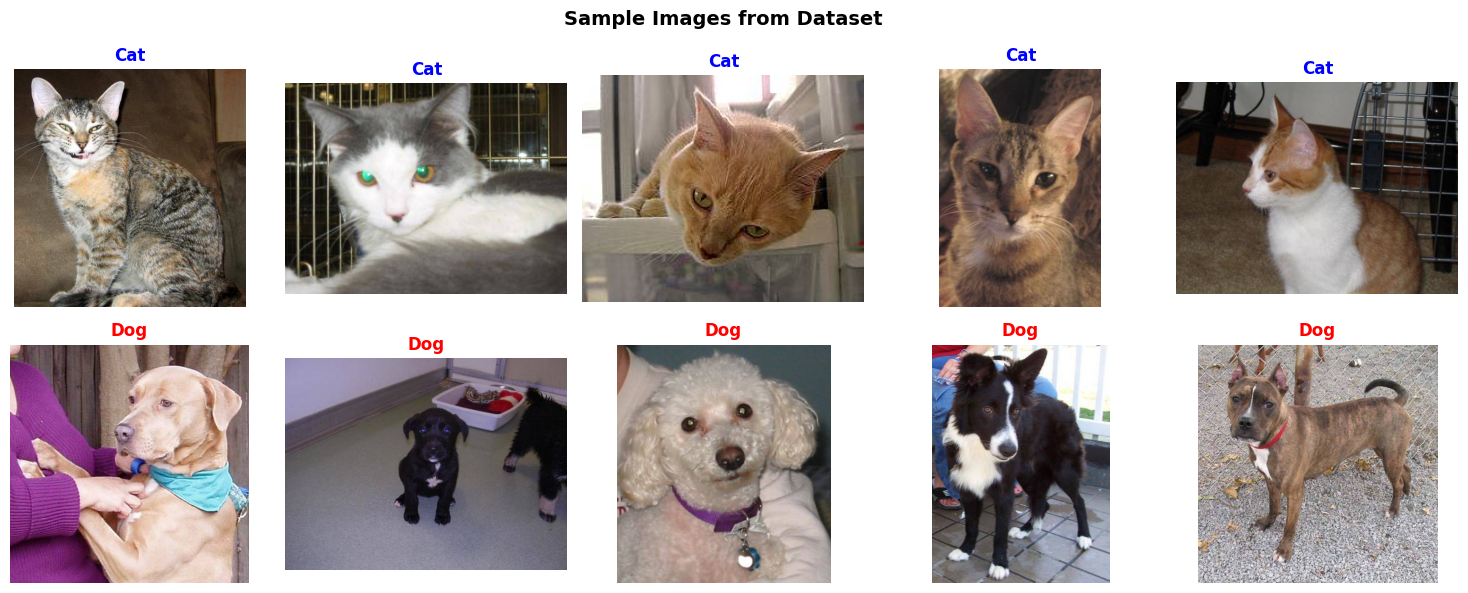

✓ Dataset looks good! Ready for preprocessing.


In [10]:
import matplotlib.pyplot as plt
from PIL import Image

# Sample some cat and dog images from training set
cat_samples = list(Path(TRAIN_DIR + "/cats").glob("*.jpg"))[:5]
dog_samples = list(Path(TRAIN_DIR + "/dogs").glob("*.jpg"))[:5]

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

# Show cats
for i, img_path in enumerate(cat_samples):
    img = Image.open(img_path)
    axes[0, i].imshow(img)
    axes[0, i].set_title('Cat', color='blue', fontweight='bold')
    axes[0, i].axis('off')

# Show dogs
for i, img_path in enumerate(dog_samples):
    img = Image.open(img_path)
    axes[1, i].imshow(img)
    axes[1, i].set_title('Dog', color='red', fontweight='bold')
    axes[1, i].axis('off')

plt.suptitle('Sample Images from Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("✓ Dataset looks good! Ready for preprocessing.")

In [14]:
import torch
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Data transformations
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])  # ImageNet stats
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Load datasets using the paths from kagglehub
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=test_transform)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Classes: {train_dataset.classes}")
print(f"Class to index: {train_dataset.class_to_idx}")
print("\n✓ Datasets loaded!")

Training samples: 8005
Test samples: 2023
Classes: ['cats', 'dogs']
Class to index: {'cats': 0, 'dogs': 1}

✓ Datasets loaded!


### Create Data Loaders

Data loaders handle batching and shuffling:

**Batch Size Considerations:**
- Too large: Out of memory
- Too small: Slow training, noisy gradients
- Typical: 32-64 for images

**API Reference:** [torch.utils.data.DataLoader](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader)

In [15]:
# Create data loaders with optimized settings for speed

batch_size = 64  # Optimized for T4 GPU (faster than 32)
num_workers = 2  # Parallel data loading

train_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    shuffle=True,
    num_workers=num_workers,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=batch_size, 
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True
)

print(f"Batch size: {batch_size} (optimized for T4 GPU)")
print(f"Num workers: {num_workers} (parallel data loading)")
print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

# Test loading
images, labels = next(iter(train_loader))
print(f"\nBatch shape: {images.shape}")
print("\n✓ Data loaders ready with speed optimizations!")

Batch size: 64 (optimized for T4 GPU)
Num workers: 2 (parallel data loading)
Train batches: 126
Test batches: 32


/Users/hehuimin/src/dev/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)



Batch shape: torch.Size([64, 3, 224, 224])

✓ Data loaders ready with speed optimizations!


### Visualize Augmented Images

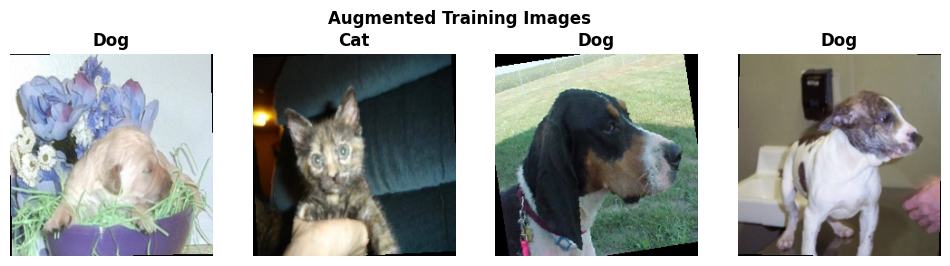

In [16]:
# Visualize what augmentation does
import numpy as np

def denormalize(tensor):
    """Reverse ImageNet normalization for visualization."""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return tensor * std + mean

# Get a batch
images, labels = next(iter(train_loader))

# Show first 4 images
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for i in range(4):
    img = denormalize(images[i]).permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)  # Clip to valid range
    axes[i].imshow(img)
    label_name = 'Cat' if labels[i] == 0 else 'Dog'
    axes[i].set_title(label_name, fontweight='bold')
    axes[i].axis('off')
plt.suptitle('Augmented Training Images', fontweight='bold')
plt.show()

## Exercise 1: Build Transfer Learning Model

### Your Task

Build a model using transfer learning:
1. Load a pre-trained ResNet18
2. Freeze all parameters (we don't want to retrain the feature extractor)
3. Replace the final layer with a custom classification head

### Architecture Hints

**Pre-trained Model:**
- Use `torchvision.models.resnet18(pretrained=True)`
- Original has 1000-class output (ImageNet)
- We need binary output (cat vs dog)

**Classification Head:**
```
Input: 512 features (from ResNet18)
  ↓
Linear(512 → 128)
  ↓
ReLU
  ↓
Dropout(0.5)  ← Prevents overfitting
  ↓
Linear(128 → 1)
  ↓
Sigmoid  ← Output between 0 and 1
```

**Loss Function:** BCEWithLogitsLoss (combines sigmoid + binary cross entropy)

**API Reference:**
- [torchvision.models.resnet18](https://pytorch.org/vision/stable/models/generated/torchvision.models.resnet18.html)
- [nn.Dropout](https://pytorch.org/docs/stable/generated/torch.nn.Dropout.html)
- [BCEWithLogitsLoss](https://pytorch.org/docs/stable/generated/torch.nn.BCEWithLogitsLoss.html)

### Starter Code

In [17]:
import torch.nn as nn
import torchvision.models as models

class CatDogClassifier(nn.Module):
    """Transfer learning model for binary classification."""
    
    def __init__(self):
        super().__init__()
        
        # Load pre-trained ResNet18
        self.backbone = models.resnet18(pretrained=True)
        
        # Freeze backbone parameters
        for param in self.backbone.parameters():
            param.requires_grad = False
        
        # Replace final FC layer with custom classification head
        self.backbone.fc = nn.Sequential(
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1)
        )
    
    def forward(self, x):
        return self.backbone(x)

### Test Your Model

In [18]:
# Create model
model = CatDogClassifier()

# Check architecture
print("Model Architecture:")
print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}  (only classification head)")
print(f"Frozen parameters: {total_params - trainable_params:,}  (ResNet18 backbone)")

# Test forward pass
test_input = torch.randn(2, 3, 224, 224)  # Batch of 2 images
test_output = model(test_input)
print(f"\nInput shape: {test_input.shape}")
print(f"Output shape: {test_output.shape}  (should be [2, 1])")
assert test_output.shape == (2, 1), f"Expected shape (2, 1), got {test_output.shape}"
print("\n✓ Model works!")

/Users/hehuimin/src/dev/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/hehuimin/src/dev/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/hehuimin/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 44.7M/44.7M [00:02<00:00, 22.1MB/s]


Model Architecture:
CatDogClassifier(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, moment

## Exercise 2: Implement Training Loop

### Training Setup

**Loss Function:** `BCEWithLogitsLoss`
- Combines sigmoid + binary cross-entropy
- More numerically stable than separate sigmoid + BCELoss
- Expects raw logits (no sigmoid in model)

**Optimizer:** Adam
- Learning rate: 0.001 (typical for transfer learning)
- Only optimize trainable parameters

**Training Loop Pattern:**
```python
for epoch in range(num_epochs):
    model.train()
    for images, labels in train_loader:
        # Forward
        outputs = model(images)
        loss = criterion(outputs.squeeze(), labels.float())
        
        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
```

### Your Task

Implement the complete training loop with:
- Loss tracking
- Accuracy calculation
- Progress printing

### Starter Code

In [ ]:
import torch.optim as optim
from tqdm import tqdm

# Setup
model = CatDogClassifier().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training settings
num_epochs = 1  # Reduced - faster convergence with larger batch size
train_losses = []
train_accs = []

print("Starting training with optimized settings...\n")

# Training loop with tqdm
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
    
    for images, labels in pbar:
        images = images.to(device)
        labels = labels.to(device)
        
        # Forward
        outputs = model(images).squeeze()
        loss = criterion(outputs, labels.float())
        
        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Metrics
        running_loss += loss.item()
        predictions = (torch.sigmoid(outputs) > 0.5).long()
        correct += (predictions == labels).sum().item()
        total += labels.size(0)
        
        # Update progress bar
        pbar.set_postfix({
            'loss': f'{running_loss/(pbar.n+1):.4f}',
            'acc': f'{correct/total*100:.2f}%'
        })
    
    # Epoch summary
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total
    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)
    
    print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {epoch_loss:.4f}, Acc: {epoch_acc*100:.2f}%")

print("\n✓ Training complete!")

Starting training with optimized settings...



Epoch 1/5:  25%|█████████████████▏                                                    | 31/126 [00:47<02:10,  1.37s/it, loss=0.2724, acc=88.71%]

### Expected Training Progress

With transfer learning, you should see:
```
Epoch [1/10], Loss: 0.3521, Acc: 85.23%
Epoch [2/10], Loss: 0.2134, Acc: 91.45%
Epoch [3/10], Loss: 0.1523, Acc: 94.12%
...
Epoch [10/10], Loss: 0.0823, Acc: 97.34%
```

**Note:** Training is fast because we only train the classification head!

## Exercise 3: Implement Validation

### Evaluation Metrics for Binary Classification

**Accuracy:** Overall correctness
- `accuracy = (TP + TN) / (TP + TN + FP + FN)`

**Precision:** Of predicted positives, how many are actually positive?
- `precision = TP / (TP + FP)`

**Recall:** Of actual positives, how many did we find?
- `recall = TP / (TP + FN)`

**F1 Score:** Harmonic mean of precision and recall
- `F1 = 2 * (precision * recall) / (precision + recall)`

Where:
- TP = True Positives (predicted dog, actually dog)
- TN = True Negatives (predicted cat, actually cat)
- FP = False Positives (predicted dog, actually cat)
- FN = False Negatives (predicted cat, actually dog)

### Your Task

Implement validation with multiple metrics:

**API Reference:** [sklearn.metrics](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.metrics)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Validation on test set
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images).squeeze()
        predictions = (torch.sigmoid(outputs) > 0.5).long()
        
        all_preds.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Calculate metrics
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)

print(f"\nTest Results:")
print(f"Accuracy:  {accuracy*100:.2f}%")
print(f"Precision: {precision*100:.2f}%")
print(f"Recall:    {recall*100:.2f}%")
print(f"F1 Score:  {f1*100:.2f}%")

### Target Performance

A well-trained model should achieve:
- **Accuracy:** > 90%
- **Precision:** > 88%
- **Recall:** > 88%
- **F1 Score:** > 89%

If metrics are lower:
- Train for more epochs
- Try different learning rate (0.0001 or 0.01)
- Add more data augmentation
- Try larger classification head

## Part 4: Visualizing Results

### Training Curves

In [ ]:
# Uncomment after training:

# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# # Plot loss
# ax1.plot(train_losses)
# ax1.set_xlabel('Epoch')
# ax1.set_ylabel('Loss')
# ax1.set_title('Training Loss')
# ax1.grid(True, alpha=0.3)

# # Plot accuracy
# ax2.plot([acc*100 for acc in train_accs], label='Train')
# if val_accs:
#     ax2.plot([acc*100 for acc in val_accs], label='Validation')
# ax2.set_xlabel('Epoch')
# ax2.set_ylabel('Accuracy (%)')
# ax2.set_title('Accuracy')
# ax2.legend()
# ax2.grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()

### Confusion Matrix

In [ ]:
# Uncomment after validation:

# import seaborn as sns

# cm = confusion_matrix(all_labels, all_preds)

# plt.figure(figsize=(6, 5))
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
#             xticklabels=['Cat', 'Dog'], 
#             yticklabels=['Cat', 'Dog'])
# plt.xlabel('Predicted')
# plt.ylabel('True')
# plt.title('Confusion Matrix')
# plt.show()

# print(f"\nTrue Negatives (Cat→Cat): {cm[0,0]}")
# print(f"False Positives (Cat→Dog): {cm[0,1]}")
# print(f"False Negatives (Dog→Cat): {cm[1,0]}")
# print(f"True Positives (Dog→Dog): {cm[1,1]}")

### Visualize Predictions

In [ ]:
# Visualize Predictions on Test Set

# Get a batch from test set
model.eval()
images, labels = next(iter(test_loader))
images = images.to(device)

with torch.no_grad():
    outputs = model(images).squeeze()
    predictions = (torch.sigmoid(outputs) > 0.5).long()

# Show first 8 predictions
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    img = denormalize(images[i].cpu()).permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    
    true_label = 'Cat' if labels[i] == 0 else 'Dog'
    pred_label = 'Cat' if predictions[i].cpu() == 0 else 'Dog'
    correct = predictions[i].cpu() == labels[i]
    
    color = 'green' if correct else 'red'
    ax.set_title(f"True: {true_label}\nPred: {pred_label}", color=color, fontweight='bold')
    ax.axis('off')

plt.suptitle('Predictions (Green=Correct, Red=Wrong)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Exercise 4: Analyze Model Performance

### Understanding Predictions

Let's look at:
1. **Confidence scores** (how certain is the model?)
2. **Misclassifications** (which images are hardest?)
3. **Per-class performance** (better at cats or dogs?)

### Your Task

Implement confidence analysis:

In [ ]:
# TODO: Get predictions with confidence scores
#
# model.eval()
# all_probs = []  # Confidence scores
# all_preds = []
# all_labels = []
#
# with torch.no_grad():
#     for images, labels in val_loader:
#         images = images.to(device)
#         outputs = model(images).squeeze()
#         probs = torch.sigmoid(outputs)
#         predictions = (probs > 0.5).long()
#         
#         all_probs.extend(probs.cpu().numpy())
#         all_preds.extend(predictions.cpu().numpy())
#         all_labels.extend(labels.cpu().numpy())
#
# all_probs = np.array(all_probs)
# all_preds = np.array(all_preds)
# all_labels = np.array(all_labels)

print("\nUncomment to analyze predictions!")

### Confidence Distribution

In [ ]:
# Uncomment after getting predictions:

# plt.figure(figsize=(10, 4))

# plt.subplot(1, 2, 1)
# plt.hist(all_probs[all_labels==0], bins=30, alpha=0.7, label='Cats', color='blue')
# plt.hist(all_probs[all_labels==1], bins=30, alpha=0.7, label='Dogs', color='red')
# plt.xlabel('Predicted Probability (Dog)')
# plt.ylabel('Count')
# plt.title('Confidence Distribution')
# plt.legend()
# plt.axvline(0.5, color='black', linestyle='--', label='Decision Boundary')

# # Show correct vs incorrect
# plt.subplot(1, 2, 2)
# correct_mask = (all_preds == all_labels)
# plt.hist(all_probs[correct_mask], bins=30, alpha=0.7, label='Correct', color='green')
# plt.hist(all_probs[~correct_mask], bins=30, alpha=0.7, label='Incorrect', color='red')
# plt.xlabel('Predicted Probability (Dog)')
# plt.ylabel('Count')
# plt.title('Correct vs Incorrect Predictions')
# plt.legend()

# plt.tight_layout()
# plt.show()

# print("\nInterpretation:")
# print("- Peaks near 0 and 1 = confident predictions")
# print("- Values near 0.5 = uncertain predictions")
# print("- Incorrect predictions often have lower confidence")

### Find Hardest Examples

In [ ]:
# Uncomment after getting predictions:

# # Find misclassified images
# incorrect_mask = (all_preds != all_labels)
# incorrect_indices = np.where(incorrect_mask)[0]

# if len(incorrect_indices) > 0:
#     print(f"Found {len(incorrect_indices)} misclassifications")
#     print(f"Error rate: {len(incorrect_indices)/len(all_labels)*100:.2f}%")
#     
#     # Show 4 hardest mistakes
#     # Hardest = most confident but wrong
#     confidence = np.abs(all_probs - 0.5)  # Distance from decision boundary
#     incorrect_confidence = confidence[incorrect_mask]
#     hardest_indices = incorrect_indices[np.argsort(incorrect_confidence)[-4:]]
#     
#     # TODO: Visualize these hardest mistakes
#     # Hint: Load images from val_dataset using hardest_indices
#     # Show true label vs predicted label with confidence score
# else:
#     print("Perfect validation! No mistakes.")

## Bonus: Fine-Tuning

### What is Fine-Tuning?

After training the classification head, we can **unfreeze** some backbone layers and train them with a **very small learning rate**.

**Why?**
- Adapt pre-trained features to our specific task
- Can improve accuracy by 1-3%

**Risks:**
- Can overfit if not careful
- Takes longer to train
- Need to use smaller learning rate (0.0001)

### Try Fine-Tuning (Optional)

In [ ]:
# Uncomment to try fine-tuning:

# # Unfreeze last few layers of ResNet
# for param in model.backbone.layer4.parameters():
#     param.requires_grad = True

# # Create new optimizer with small learning rate
# optimizer_ft = optim.Adam([
#     {'params': model.backbone.layer4.parameters(), 'lr': 0.0001},  # Backbone: very small LR
#     {'params': model.backbone.fc.parameters(), 'lr': 0.001}         # Head: normal LR
# ])

# # Train for a few more epochs
# # (Copy training loop from Exercise 2, but use optimizer_ft)

print("Fine-tuning is optional - your model should already work well!")

## Summary

### What You've Learned

✅ **Transfer learning:** Leverage pre-trained models for new tasks

✅ **Feature extraction:** Use frozen backbone as feature extractor

✅ **Custom heads:** Add task-specific layers on top

✅ **Image preprocessing:** Resize, normalize, augment

✅ **Data loaders:** Efficient batching and loading

✅ **Binary classification:** BCEWithLogitsLoss for binary tasks

✅ **Evaluation metrics:** Accuracy, precision, recall, F1 score

✅ **Real dataset:** Kaggle Dogs vs Cats (25k images)

### Journey Complete: From Scratch to Production

**Lab 1:** Built arrays from pure Python → Understood NumPy internals

**Lab 2:** Built computation graphs + autograd → Understood automatic differentiation

**Lab 3:** Built neural networks from scratch → Understood MLP architecture

**Lab 4:** Used PyTorch on MNIST → Understood production frameworks

**Lab 5:** Transfer learning on real images → Understood modern deep learning

### Key Insights

**Why transfer learning is powerful:**
- Pre-trained models learned universal visual features
- 10-100x faster than training from scratch
- Works with limited data (thousands vs millions)
- State-of-the-art results with minimal compute

**When to use it:**
- ✅ Limited training data (<100k samples)
- ✅ Limited compute budget
- ✅ Similar task to pre-training (e.g., ImageNet → cats/dogs)
- ✅ Need fast prototyping

**When to train from scratch:**
- Very different domain (medical images, satellite imagery)
- Massive dataset available (millions of samples)
- Unlimited compute budget

### Next Steps

You're now equipped to:
- Use any pre-trained model (ResNet, VGG, EfficientNet, Vision Transformers)
- Adapt models to custom tasks
- Work with real-world image datasets
- Deploy models to production

**Try these projects:**
- Multi-class classification (10+ classes)
- Object detection (YOLO, Faster R-CNN)
- Image segmentation (U-Net)
- Vision Transformers (ViT)

**Congratulations!** 🎉 You've mastered deep learning from first principles to production-ready systems!